In [30]:
# Task 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
# Task 2: Load Dataset

df = pd.read_csv("ToyotaCorolla - MLR.csv")

print(df.head())

   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  


In [3]:
# Task 3: Display Dataset Information

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB
None


In [4]:
# Task 4: Statistical Summary

print(df.describe())

              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                cc        Doors  Cylinders        Gears      Weight  
count   1436.00000  1436.000000     1436.0  1436.000000  1436.00000  
mean    1576.85585     4.033426        4.0     5.026462  1072.45961  
std      424.38677     0.952677        0.0     0.188510    52.64112  
min     1300.00000     2.0

In [5]:
# Task 5: Check Missing Values

print(df.isnull().sum())

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


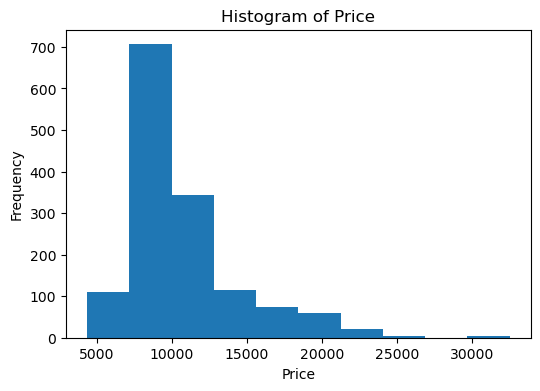

In [6]:
# Task 6: Histogram for Price

plt.figure(figsize=(6,4))

plt.hist(df['Price'], bins=10)

plt.title("Histogram of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

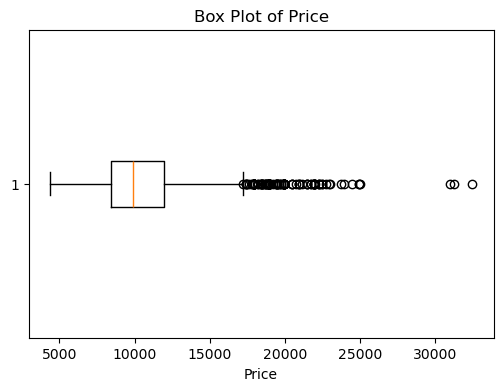

In [7]:
# Task 7: Box Plot for Price

plt.figure(figsize=(6,4))

plt.boxplot(df['Price'], vert=False)

plt.title("Box Plot of Price")
plt.xlabel("Price")

plt.show()

In [40]:
# Task 8: Convert Categorical Data into Numerical Data

categorical_columns = df.select_dtypes(include=['object']).columns

print(categorical_columns)

df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

print(df.head())

Index(['Fuel_Type'], dtype='object')
   Price  Age_08_04     KM  HP  Automatic    cc  Doors  Cylinders  Gears  \
0  13500         23  46986  90          0  2000      3          4      5   
1  13750         23  72937  90          0  2000      3          4      5   
2  13950         24  41711  90          0  2000      3          4      5   
3  14950         26  48000  90          0  2000      3          4      5   
4  13750         30  38500  90          0  2000      3          4      5   

   Weight  Fuel_Type_Diesel  Fuel_Type_Petrol  
0    1165              True             False  
1    1165              True             False  
2    1165              True             False  
3    1165              True             False  
4    1170              True             False  


In [41]:
# Task 9: Define Independent and Dependent Variables

X = df.drop('Price', axis=1)

y = df['Price']

In [42]:
# Task 10: Split Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1148, 11)
(288, 11)


In [43]:
# Task 11: Build Multiple Linear Regression Model

from sklearn.linear_model import LinearRegression

model1 = LinearRegression()

model1.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [44]:
# Task 12: Model Coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model1.coef_
})

print(coefficients)

             Feature   Coefficient
0          Age_08_04 -1.208305e+02
1                 KM -1.623141e-02
2                 HP  1.403948e+01
3          Automatic  1.488309e+02
4                 cc -3.037219e-02
5              Doors -6.031097e+01
6          Cylinders -8.242296e-13
7              Gears  5.516007e+02
8             Weight  2.588496e+01
9   Fuel_Type_Diesel -6.854876e+01
10  Fuel_Type_Petrol  1.370809e+03


In [45]:
# Task 13: Predict Test Data

y_pred = model1.predict(X_test)

print(y_pred[:5])

[11137.15453645  8974.9731327   9283.27025955  8951.97440751
 10082.31592852]


In [46]:
# Task 14: Evaluate Model Performance

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 990.8872739193923
MSE: 2203043.823143702
RMSE: 1484.2654153296512
R2 Score: 0.8348888040611082


In [47]:
# Task 15: Build Second Model Using Selected Features

X2 = df[['Age_08_04', 'KM', 'HP', 'Weight']]

y2 = df['Price']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42
)

model2 = LinearRegression()

model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)

print("Second Model R2 Score:", r2_score(y2_test, y2_pred))

Second Model R2 Score: 0.8506068681500583


In [48]:
# Task 16: Build Third Model

X3 = df[['Age_08_04', 'KM', 'cc', 'Doors', 'Weight']]

y3 = df['Price']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3,
    test_size=0.2,
    random_state=42
)

model3 = LinearRegression()

model3.fit(X3_train, y3_train)

y3_pred = model3.predict(X3_test)

print("Third Model R2 Score:", r2_score(y3_test, y3_pred))

Third Model R2 Score: 0.832307570086617


In [49]:
# Task 17: Apply Ridge Regression

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

print("Ridge R2 Score:", r2_score(y_test, ridge_pred))

Ridge R2 Score: 0.8351359377712337


In [50]:
# Task 18: Apply Lasso Regression

from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

print("Lasso R2 Score:", r2_score(y_test, lasso_pred))

Lasso R2 Score: 0.8354626403967389


In [51]:
# Task 19: Conclusion

print("Multiple Linear Regression analysis completed successfully.")

print("Different regression models were built and evaluated.")

print("Ridge and Lasso regression helped reduce overfitting and handle multicollinearity.")

Multiple Linear Regression analysis completed successfully.
Different regression models were built and evaluated.
Ridge and Lasso regression helped reduce overfitting and handle multicollinearity.


In [37]:
# Interview Question 1

print("Normalization scales data between 0 and 1.")

print("Standardization converts data into mean 0 and standard deviation 1.")

print("Both techniques help improve machine learning model performance.")

Normalization scales data between 0 and 1.
Standardization converts data into mean 0 and standard deviation 1.
Both techniques help improve machine learning model performance.


In [39]:
# Interview Question 2

print("Techniques to handle multicollinearity:")

print("1. Remove highly correlated variables")

print("2. Use Ridge Regression")

print("3. Use Lasso Regression")

print("4. Apply Principal Component Analysis ")

Techniques to handle multicollinearity:
1. Remove highly correlated variables
2. Use Ridge Regression
3. Use Lasso Regression
4. Apply Principal Component Analysis 
